In [1]:
import os
import moxing as mox
import mindspore as ms
from mindspore import context, nn
from mindspore.dataset import ImageFolderDataset
from mindspore.dataset.vision import c_transforms as C
from mindspore.dataset.transforms import c_transforms as TC
from mindspore.common.initializer import XavierUniform

context.set_context(
    mode=context.GRAPH_MODE,
    device_target="CPU"   
)

print("MindSpore version:", ms.__version__)


INFO:root:Using MoXing-v2.1.0.5d9c87c8-5d9c87c8
INFO:root:Using OBS-Python-SDK-3.20.9.1


MindSpore version: 1.7.0


In [2]:
OBS_TRAIN_PATH = "obs://jonat/dataset/train"
LOCAL_TRAIN_PATH = "/cache/train"

os.makedirs(LOCAL_TRAIN_PATH, exist_ok=True)

print("Copying dataset from OBS...")
mox.file.copy_parallel(OBS_TRAIN_PATH, LOCAL_TRAIN_PATH)
print("Dataset copied")

classes = os.listdir(LOCAL_TRAIN_PATH)
num_classes = len(classes)
print("Classes:", classes)


Copying dataset from OBS...


/home/ma-user/anaconda3/envs/MindSpore/lib/python3.7/site-packages/requests/__init__.py:104: RequestsDependencyWarning: urllib3 (1.26.12) or chardet (5.2.0)/charset_normalizer (2.0.12) doesn't match a supported version!
  RequestsDependencyWarning)


Dataset copied
Classes: ['autistic', 'non_autistic']


In [3]:
batch_size = 2
image_size = 224

dataset = ImageFolderDataset(
    dataset_dir=LOCAL_TRAIN_PATH,
    shuffle=True
)

transforms = [
    C.Decode(),
    C.Resize((image_size, image_size)),
    C.RandomHorizontalFlip(),
    C.Rescale(1.0 / 255.0, 0.0),
    C.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
    C.HWC2CHW()
]

type_cast = TC.TypeCast(ms.int32)

dataset = dataset.map(operations=transforms, input_columns="image")
dataset = dataset.map(operations=type_cast, input_columns="label")
dataset = dataset.batch(batch_size)
print("Total samples:", dataset.get_dataset_size())

steps_per_epoch = dataset.get_dataset_size()
print("Steps per epoch:", steps_per_epoch)


Total samples: 68
Steps per epoch: 68


In [4]:
dataset_raw = ImageFolderDataset("/cache/train", shuffle=False)
print("Raw samples:", dataset_raw.get_dataset_size())


Raw samples: 135


In [5]:
from mindspore import nn

test = nn.Conv2d(
    3, 64,
    kernel_size=7,
    stride=2,
    pad_mode="pad",
    padding=3,
    has_bias=False
)

print("Conv2d OK")


Conv2d OK


In [6]:
batch_size = 2
epochs = 50
learning_rate = 0.0005

print("Num classes:", num_classes)
print("Batch size:", batch_size)
print("Epochs:", epochs)


Num classes: 2
Batch size: 2
Epochs: 50


In [7]:
class BasicBlock(nn.Cell):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            pad_mode="pad",
            padding=1,
            has_bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            pad_mode="pad",
            padding=1,
            has_bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.SequentialCell(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    pad_mode="pad",
                    padding=0,
                    has_bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )

    def construct(self, x):
        identity = x
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        if self.downsample:
            identity = self.downsample(identity)
        return self.relu(x + identity)


In [8]:
from mindspore.ops import operations as P

class ResNet18(nn.Cell):
    def __init__(self, num_classes):
        super().__init__()

        self.conv1 = nn.Conv2d(
            3, 64,
            kernel_size=7,
            stride=2,
            pad_mode="pad",
            padding=3,
            has_bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, pad_mode="same")

        self.layer1 = self._make_layer(64, 64, 2, 1)
        self.layer2 = self._make_layer(64, 128, 2, 2)
        self.layer3 = self._make_layer(128, 256, 2, 2)
        self.layer4 = self._make_layer(256, 512, 2, 2)

        self.reduce_mean = P.ReduceMean(keep_dims=False)
        self.fc = nn.Dense(512, num_classes)

    def _make_layer(self, in_ch, out_ch, blocks, stride):
        layers = [BasicBlock(in_ch, out_ch, stride)]
        for _ in range(1, blocks):
            layers.append(BasicBlock(out_ch, out_ch))
        return nn.SequentialCell(layers)

    def construct(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.reduce_mean(x, (2, 3))  # Global Average Pooling
        x = self.fc(x)
        return x


In [9]:
net = ResNet18(num_classes)
print("Model built successfully")


Model built successfully


In [13]:
import numpy as np
from collections import defaultdict

def per_class_accuracy(net, dataset, class_names):
    net.set_train(False)

    correct = defaultdict(int)
    total = defaultdict(int)

    for data in dataset.create_dict_iterator():
        logits = net(data["image"])
        preds = np.argmax(logits.asnumpy(), axis=1)
        labels = data["label"].asnumpy()

        for p, t in zip(preds, labels):
            total[t] += 1
            if p == t:
                correct[t] += 1

    net.set_train(True)

    print("\nPer-class accuracy:")
    for idx, name in enumerate(class_names):
        acc = correct[idx] / total[idx] if total[idx] > 0 else 0
        print(f"Class '{name}': accuracy = {acc:.2f}")


In [16]:
import os
import moxing as mox

OBS_VAL_PATH = "obs://jonat/dataset/val"
LOCAL_VAL_PATH = "/cache/val"

# Create local dir
os.makedirs(LOCAL_VAL_PATH, exist_ok=True)

# Copy data from OBS → local cache
mox.file.copy_parallel(OBS_VAL_PATH, LOCAL_VAL_PATH)

# Get class names (only directories)
class_names = sorted(
    d for d in os.listdir(LOCAL_VAL_PATH)
    if os.path.isdir(os.path.join(LOCAL_VAL_PATH, d))
)

print("Class names:", class_names)

# Run per-class accuracy
per_class_accuracy(net, dataset, class_names)


Class names: ['autistic', 'non_autistic']

Per-class accuracy:
Class 'autistic': accuracy = 0.30
Class 'non_autistic': accuracy = 0.76


Class 'autistic': accuracy = 0.33
Class 'non_autistic': accuracy = 0.69


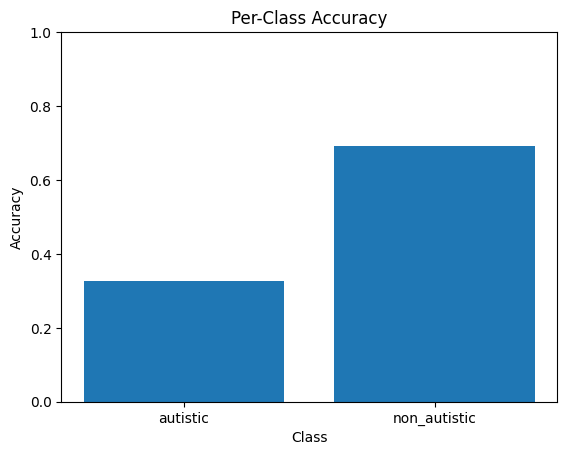

In [18]:
import matplotlib.pyplot as plt
from collections import defaultdict
from mindspore.ops import operations as P

# Argmax op
argmax = P.Argmax(axis=1)

# Accumulators
correct = defaultdict(int)
total = defaultdict(int)

net.set_train(False)

for data in dataset.create_dict_iterator():
    logits = net(data["image"])
    preds = argmax(logits).asnumpy()
    labels = data["label"].asnumpy()

    for p, t in zip(preds, labels):
        total[int(t)] += 1
        if int(p) == int(t):
            correct[int(t)] += 1

net.set_train(True)

# Compute accuracy per class
class_acc = []
for idx, name in enumerate(class_names):
    acc = correct[idx] / total[idx] if total[idx] > 0 else 0.5
    class_acc.append(acc)
    print(f"Class '{name}': accuracy = {acc:.2f}")

# ---- Plot ----
plt.figure()
plt.bar(class_names, class_acc)
plt.xlabel("Class")
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy")
plt.ylim(0, 1.0)
plt.show()
